## Disciplina VIS101: Fundamentos em Visão Computacional

Este é o primeiro contato com código da disciplina. O objetivo é estabelecer a representação que usaremos o curso inteiro: a imagem como uma matriz de intensidades. Partimos de carregar e inspecionar uma imagem e chegamos ao primeiro passo de um sistema de visão, a detecção de bordas.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
img = cv2.imread('../images/apple.jpg')
print('Tipo da imagem:', type(img))
print('Forma da imagem (altura, largura, canais):', img.shape)
print('Valores:', img.dtype, 'de', img.min(), 'a', img.max())

Tipo da imagem: <class 'numpy.ndarray'>
Forma da imagem (altura, largura, canais): (853, 1280, 3)
Valores: uint8 de 0 a 255


## Visualizar a imagem

O matplotlib espera os canais na ordem RGB, mas o OpenCV usa BGR, então precisamos corrigir antes de exibir.

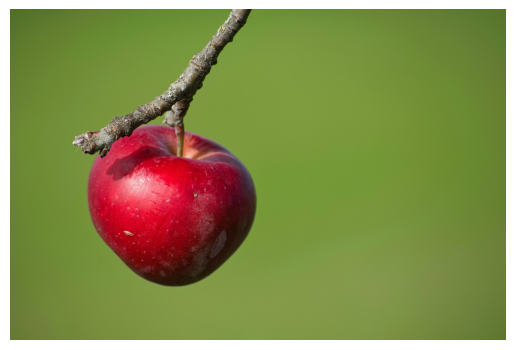

In [3]:
plt.imshow(img[:, : , ::-1])    # BGR para RGB
plt.axis('off')
plt.show()

## Pixels e regiões de interesse

Por ser um array, acessar um pixel é indexar a matriz, e recortar uma região de interesse é fatiar o array, como em qualquer estrutura numpy.

In [4]:
pixel = img[400, 600]
print('Pixel na linha 600 e coluna 600 (ordem: RGB):', pixel[::-1]) # BGR para RGB

Pixel na linha 600 e coluna 600 (ordem: RGB): [106 114 116]


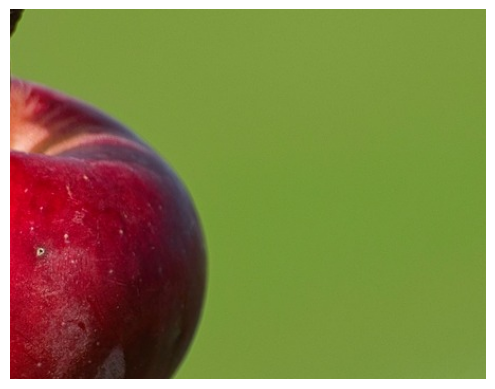

In [5]:
roi = img[250:600, 450:900]
plt.imshow(roi[:, : , ::-1])    # BGR para RGB
plt.axis('off')
plt.show()

## Os canais de cor

Cada canal, é por si só uma matriz de intensidades. Podemos visualizar cada cadal em separado. 

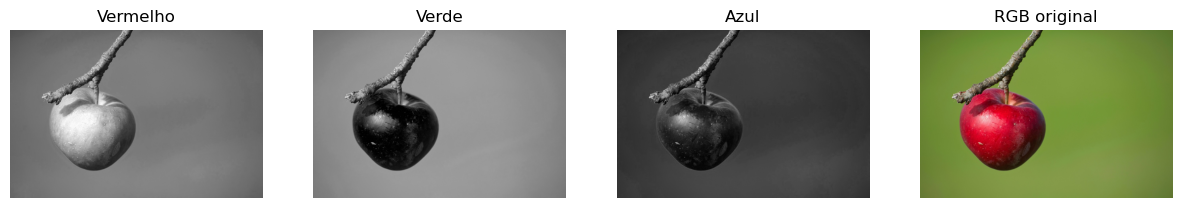

In [6]:
B, G, R = cv2.split(img)

fig, ax = plt.subplots(1, 4, figsize=(15, 5))
for canal, canais, nome in zip(ax, [R, G, B, img[:, : , ::-1]], ['Vermelho', 'Verde', 'Azul', 'RGB original']):
    canal.imshow(canais, cmap = 'gray')
    canal.set_title(nome)
    canal.axis('off')
plt.show()

## Da imagem às bordas

Uma borda é um ponto onde a intensidade muda rapidamente, e medir variação é o papel do gradiente. Trabalhamos com a imagem em tons de cinza, uma única matriz de intensidades, e aproximamos o gradiente pela diferença entre pixels vizinhos.

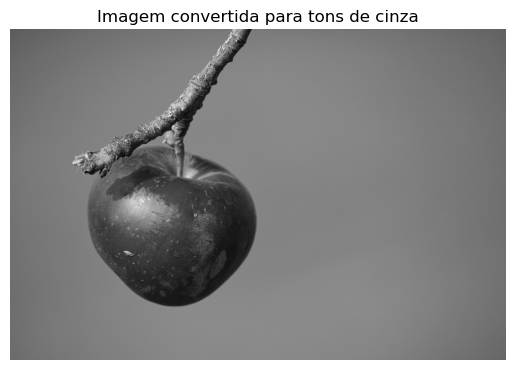

In [7]:
I  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float) # Converte a imagem para tons de cinza e transforma os valores em decimais para evitar problemas com números negativos na subtração.

plt.imshow(I, cmap = 'gray')
plt.title('Imagem convertida para tons de cinza')
plt.axis('off')
plt.show()

In [8]:
# Cria matrizes preenchidas com zeros com o mesmo tamanho da imagem original para armazenar os resultados.
I_x = np.zeros_like(I)
I_y = np.zeros_like(I)

# Calcula a variação horizontal. Subtrai o pixel da esquerda do pixel atual.
I_x[:, 1:] = I[:, 1:] - I[:, :-1]
# Calcula a variação vertical. Subtrai o pixel de cima do pixel atual.
I_y[1:, :] = I[1:, :] - I[:-1, :]

A magnitude do gradiente, pelo teorema de Pitágoras, mede a força da borda. Um pixel é declarado borda quando essa força ultrapassa um limiar.

In [9]:
G = np.sqrt(I_x ** 2 + I_y ** 2) # Calcula a magnitude do gradiente usando a equação da hipotenusa.
bordas = G > 40
print('Força máxima de borda:', round(G.max(), 1))

Força máxima de borda: 182.5


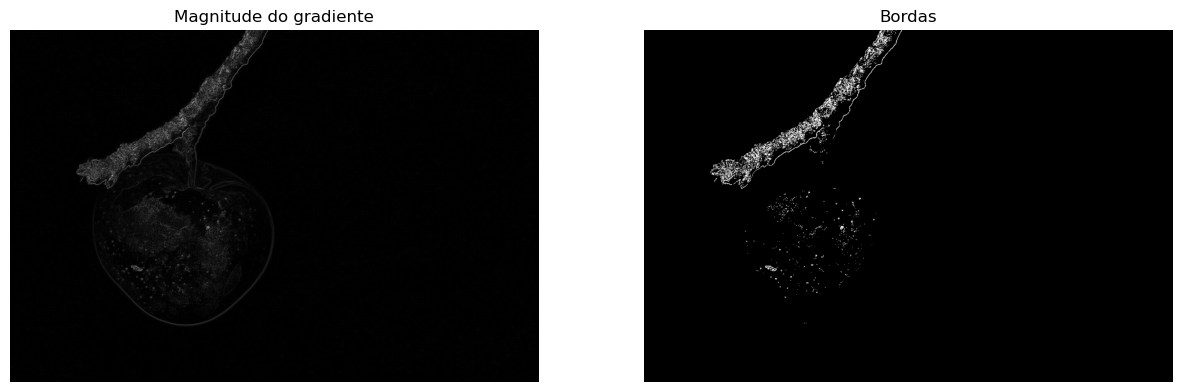

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(G, cmap = 'gray')
ax[0].set_title('Magnitude do gradiente')
ax[0].axis('off')
ax[1].imshow(bordas, cmap = 'gray')
ax[1].set_title('Bordas')
ax[1].axis('off')
plt.show()

**Síntese**

Uma imagem é uma matriz (altura, largura, canais) de valores uint8. O OpenCV usa a ordem BGR e o matplotlib espera RGB. Acessar pixels e recortar uma região é indexar e fatiar o array. Cada canal é uma matriz de intensidades. E o gradiente converte a imagem em um mapa de bordas, o ponto de partida de um sistema de visão.

## Filtro de Sobel

Saímos da imagem crua e chegamos a um mapa de bordas, o primeiro passo do sistema de visão estudado na teoria. As bibliotecas trazem um atalho para o mesmo cálculo, com um filtro mais robusto (Sobel), que será detalhado adiante.

In [11]:
Sx = cv2.Sobel(I, cv2.CV_64F, 1, 0, ksize=3)
Sy = cv2.Sobel(I, cv2.CV_64F, 0, 1, ksize=3)
G_sobel = np.sqrt(Sx**2 + Sy**2)
print('Magnitude máxima calculada com base no Teorema de Pitágoras:', round(G.max(), 1), '| Sobel:', round(G_sobel.max(), 1))

Magnitude máxima calculada com base no Teorema de Pitágoras: 182.5 | Sobel: 859.1


In [12]:
# Mantém a mesma proporção visual de corte
limiar_sobel = G_sobel.max() * 0.18

bordas_sobel = G_sobel > limiar_sobel

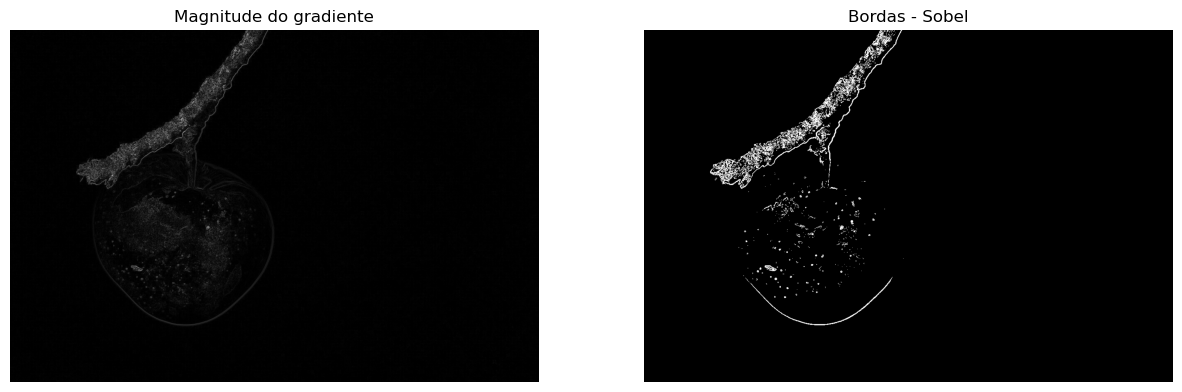

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(G, cmap = 'gray')
ax[0].set_title('Magnitude do gradiente')
ax[0].axis('off')
ax[1].imshow(bordas_sobel, cmap = 'gray')
ax[1].set_title('Bordas - Sobel')
ax[1].axis('off')
plt.show()

## Manipulação da imagem

Modificação de pixels, recorte de regiões de interesse e exploração de cores nos espaços RGB e HSV.

In [14]:
plt.rcParams.update({'figure.figsize': (6, 4), 'font.size': 12})
print('Setup pronto.')

Setup pronto.


In [15]:
print('Forma:', img.shape)

Forma: (853, 1280, 3)


## Acessando e modificando pixels

Cada pixel é um vetor de três valores na ordem B, G, R. Podemos ler o valor de um pixel e também escrever sobre uma região, sempre trabalhando em uma cópia.

In [16]:
print('Pixel (100, 200):', img[100, 200])

Pixel (100, 200): [ 51 141 106]


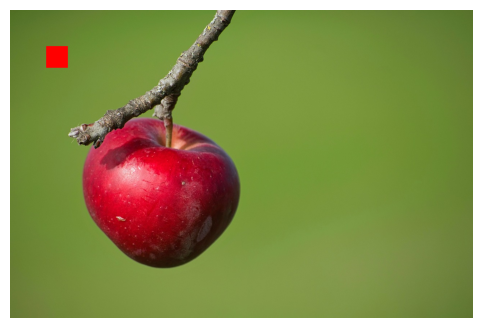

In [17]:
img_mod = img.copy()
img_mod[100:160, 100:160] = (0, 0, 255)   # bloco vermelho (B, G, R)

plt.imshow(img_mod[:, :, ::-1])
plt.axis('off')
plt.show()

## O espaço de cor HSV

O HSV separa o matiz (a cor em si) da saturação e do brilho. Isso facilita selecionar objetos por cor, algo difícil no RGB, em que a cor fica espalhada pelos três canais.

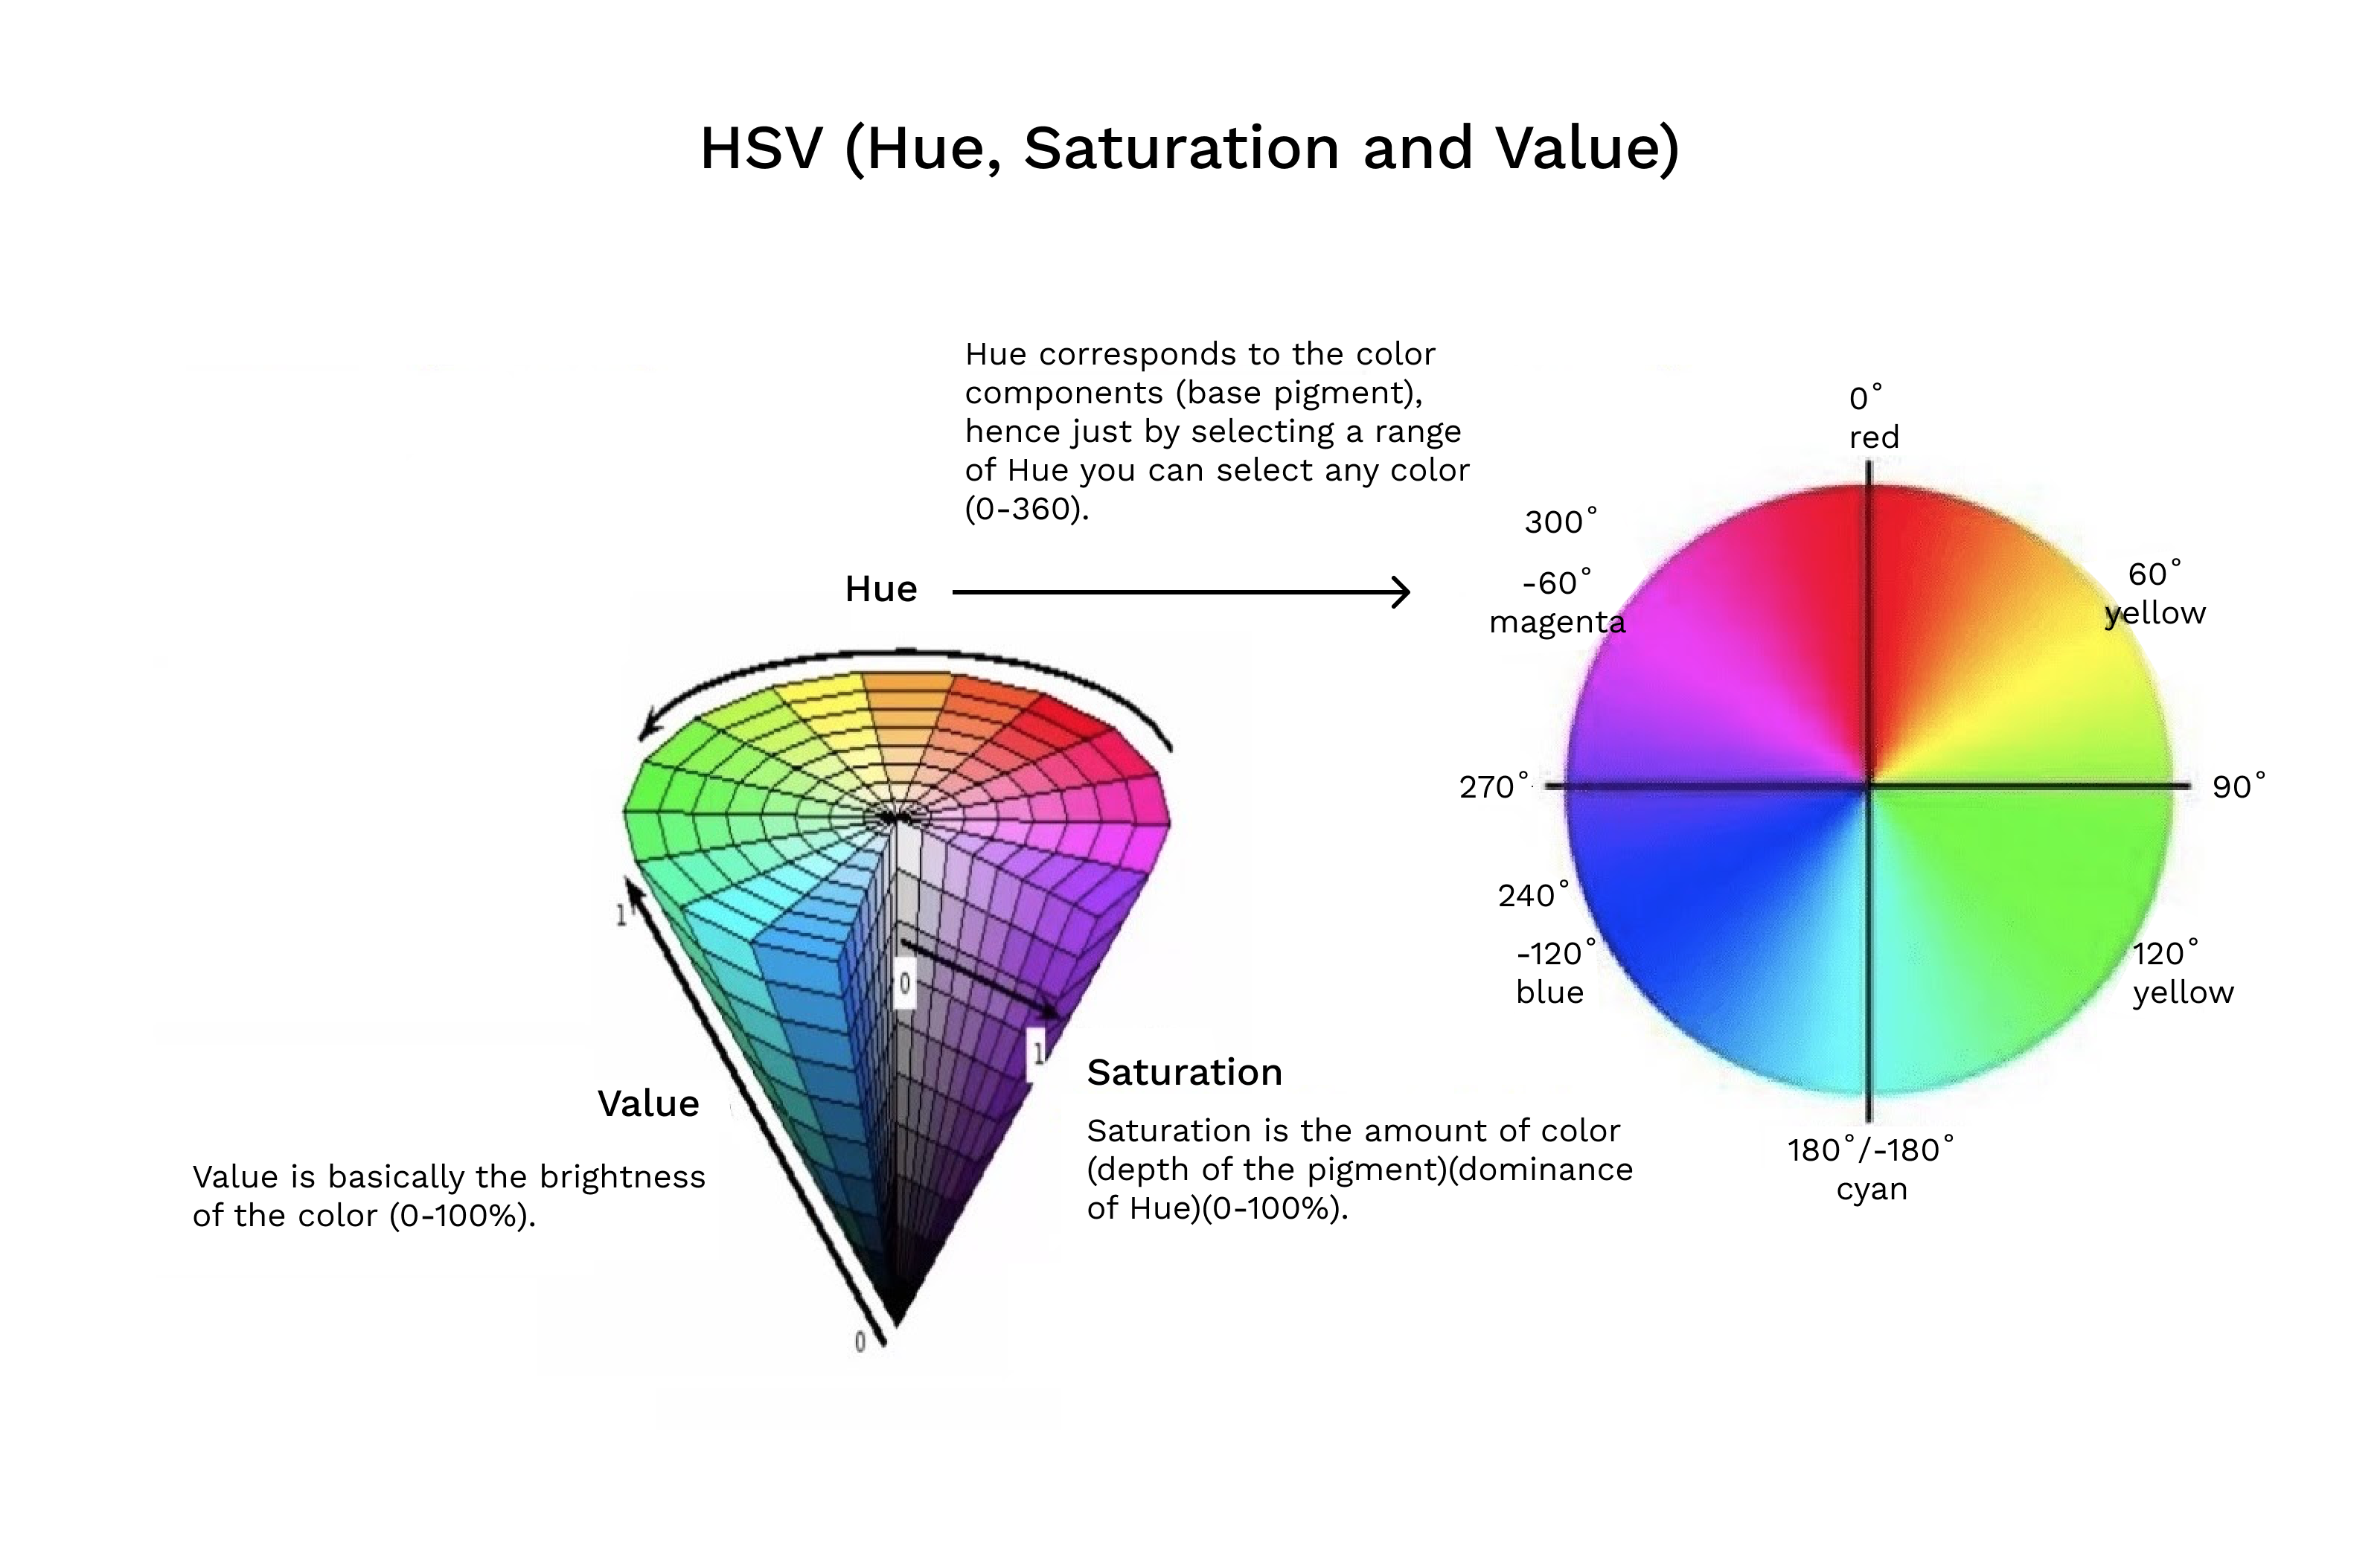

In [18]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
print('forma HSV:', hsv.shape)

forma HSV: (853, 1280, 3)


## Segmentação por Cor no Espaço HSV

Para isolar a maçã, convertemos a imagem do espaço padrão **BGR** (utilizado pelo OpenCV) para o espaço **HSV** (*Hue, Saturation, Value* ou Matiz, Saturação, Valor). 

Ao contrário do BGR, onde a cor e a iluminação estão misturadas em três canais (Azul, Verde e Vermelho), o HSV separa a informação cromática pura da luminosidade. Isso torna o algoritmo muito mais imune a variações de sombras e reflexos.

### 1. Canal H (*Hue* / Matiz) — Que cor eu quero?
* **O que representa:** É a cor pura, representada matematicamente como uma posição em um círculo cromático de 0° a 360°.
* **A limitação técnica do OpenCV:** Para que a imagem caiba em 1 byte de memória (valores de 0 a 255), os graus são divididos por 2. Assim, a escala do canal H vai de 0 a 179.
* **Intuição da escolha:** O vermelho puro fica exatamente em 0° (junção onde o círculo se fecha). Portanto, a cor vermelha ocupa as duas extremidades da régua:
  * `0 a 10`: Tons de vermelho que começam a puxar para o laranja.
  * `170 a 179`: Tons de vermelho que vieram do rosa/magenta.
  * O operador lógico OR (`|`) combina essas duas faixas para capturar o espectro completo do vermelho.

### 2. Canal S (*Saturation* / Saturação) — Quão viva é a cor?
* **O que representa:** Vai de 0 (cor totalmente desbotada, tom de cinza) a 255 (cor pura, extremamente viva).
* **Intuição da escolha `(40 a 255)`:** Áreas de sombra intensa acabam "lavando" a cor da fruta, fazendo a saturação cair. Definir o piso em **40** torna o algoritmo mais tolerante. Ele passa a incluir áreas da casca onde o vermelho está desbotado pela falta de luz direta (como a lateral direita e sombreada da maçã), mas ainda mantém um piso alto o suficiente para ignorar reflexos brancos estourados e tons acinzentados do fundo.

### 3. Canal V (*Value* / Brilho) — Quão clara está a cor?
* **O que representa:** Vai de 0 (totalmente escuro/preto) a 255 (totalmente claro/iluminado).
* **Intuição da escolha `(20 a 255)`:** Uma maçã real possui grande contraste, com áreas iluminadas e sombras profundas. Ao utilizar um limite mínimo muito alto, perdíamos a parte mais escura da maçã. Reduzir esse piso para **20** permite que o algoritmo capture pixels muito escuros (sob sombra severa), mas que ainda contêm a informação da cor vermelha da casca. O limite máximo em 255 garante que as partes mais claras também sejam incluídas na máscara.


In [19]:
faixa_baixa = cv2.inRange(hsv, (0, 40, 20), (10, 255, 255))
faixa_alta  = cv2.inRange(hsv, (170, 40, 20), (180, 255, 255))
mask = faixa_baixa | faixa_alta

pixels_selecionados = cv2.countNonZero(mask)
print('Pixels selecionados:', pixels_selecionados)

Pixels selecionados: 121879


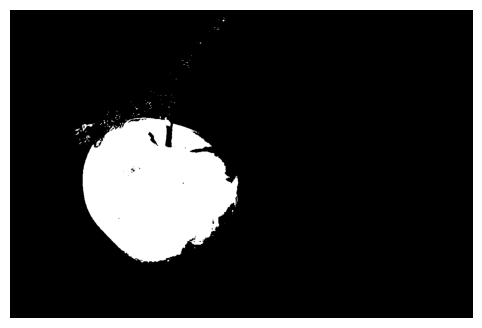

In [20]:
plt.imshow(mask, cmap = 'gray')
plt.axis('off')
plt.show()

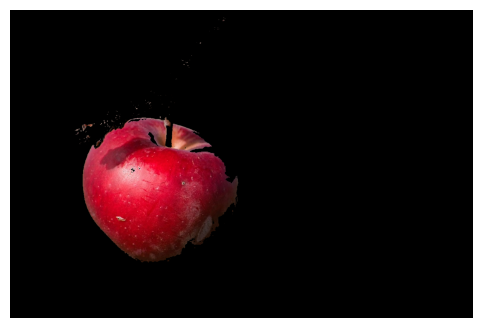

In [21]:
resultado = cv2.bitwise_and(img, img, mask=mask)

plt.imshow(resultado[:, :, ::-1])
plt.axis('off')
plt.show()

**Síntese**

Pixels são lidos e escritos por indexação, regiões por fatiamento. No RGB, a cor se distribui pelos três canais. No HSV, a matiz isola a cor, o que torna a segmentação por cor direta com uma máscara.

## Melhoria do contorno

O objetivo inicial era isolar uma maçã vermelha de seu fundo. No entanto, objetos reais possuem sombras, reflexos e variações de iluminação que fazem com que partes da própria fruta sejam ignoradas pelos filtros de cor comuns, gerando "buracos" ou recortes indesejados na borda.

Ao aplicar a máscara diretamente na imagem original o resultado apresentou falhas:

* **Buracos internos:** Causados por reflexos estourados (brancos) na casca.
* **Recortes na borda (reentrâncias):** Grandes áreas escuras de sombra que tocavam o fundo e "alteravam" o contorno da maçã.

Operações morfológicas comuns (como o *Closing*) não funcionaram porque as falhas tocavam a borda externa, conectando-se ao fundo preto.

**Solução de melhoria: Fechamento por contorno convexo (*Convex Hull*)**

Para reconstruir o formato da maçã ignorando as imperfeições de cor, adotamos a técnica do Convex Hull. O algoritmo funciona mapeando os pontos mais externos do objeto e traçando uma linha contínua entre eles.


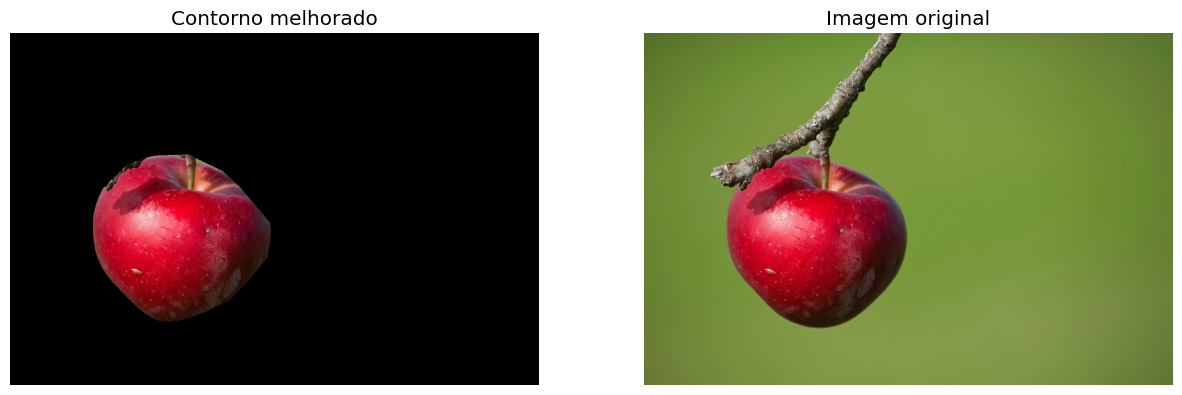

In [22]:
# Encontra os contornos da máscara original
contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Cria uma nova máscara preta de mesmo tamanho
mask_convexa = np.zeros_like(mask)

if contornos:
    # Encontra o maior contorno (a maçã)
    maior_contorno = max(contornos, key=cv2.contourArea)
    
    # Calcula o Convex Hull ao redor dela
    hull = cv2.convexHull(maior_contorno)
    
    # Desenha o contorno convexo preenchido de branco (255) na nova máscara
    cv2.drawContours(mask_convexa, [hull], -1, 255, thickness=cv2.FILLED)

# Aplica a nova máscara convexa na imagem original
resultado_melhorado = cv2.bitwise_and(img, img, mask=mask_convexa)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(resultado_melhorado[:, :, ::-1])
ax[0].set_title('Contorno melhorado')
ax[0].axis('off')
ax[1].imshow(img[:, : , ::-1])
ax[1].set_title('Imagem original')
ax[1].axis('off')
plt.show()



Apesar da melhora, ainda não temos um contorno perfeito da maçã, uma vez que algumas áreas dela foram perdidas nessa segmentação. Uma possível melhoria seria isolar o fundo verde para garantir que as partes perdidas fossem incluídas.

## Do Sobel ao recorte limpo da maçã

Começamos esse notebook detectando bordas com o gradiente e com o filtro de Sobel: um mapa de "onde a intensidade muda", mas sem noção nenhuma do que é objeto e o que é fundo. A partir daí, o objetivo evoluiu para algo mais próximo de um sistema de visão real: isolar a maçã do fundo, obtendo uma máscara limpa e um recorte fiel ao seu formato.

O primeiro caminho foi segmentar por cor no espaço HSV, buscando os tons de vermelho da maçã. Funcionou, mas trouxe dois problemas típicos de segmentação por cor: buracos nas áreas de reflexo e sombra (onde o vermelho "sai da faixa" esperada) e reentrâncias na borda, onde sombras profundas se conectavam ao fundo escuro e distorciam o contorno.

Uma primeira tentativa de correção usou o *Convex Hull*, que reconstrói a forma conectando os pontos mais externos por retas. Resolveu os buracos e as reentrâncias, mas ao custo de alterar a forma, perdendo concavidades reais da maçã.

A melhoria seguinte inverteu a lógica do problema: em vez de tentar reconhecer a maçã pela cor (algo instável por causa de sombra e brilho), passamos a isolar o **fundo**, que é bem mais uniforme e verde. Tudo o que não é fundo verde é candidato a objeto, o que já elimina naturalmente boa parte dos problemas de reentrância e buraco, sem precisar do Convex Hull.

O que sobrou depois disso foi o galho e o cabinho da maçã, ainda conectados à massa principal. Para separá-los, usamos uma sequência de operações morfológicas: **erosão** com um kernel grande o suficiente para "cortar" a conexão fina do galho, seleção do **maior componente conectado** (garantindo que nenhum fragmento do galho sobreviva), e **dilatação** de volta para restaurar o tamanho original da maçã. O contorno externo desse resultado é então preenchido diretamente, sem Convex Hull, preservando a forma orgânica da fruta.

O tamanho do kernel de erosão foi definido testando um grid de valores crescentes e observando visualmente o ponto em que aumentar o kernel deixava de mudar o resultado de forma perceptível (por volta de 85). Esse "ponto de estabilização" é um bom indício de que a conexão com o galho já foi rompida, e que qualquer erosão a mais estaria apenas afetando a massa da própria maçã, que é grande e convexa o suficiente para não mudar muito. O valor final escolhido foi 95, um pouco acima do ponto de estabilização, como margem de segurança.

Como exercício adicional, testamos identificar o resíduo do galho de forma mais cirúrgica, usando **defeitos de convexidade** (`cv2.convexityDefects`): a diferença entre o contorno real da maçã e seu Convex Hull, medida em cada reentrância. A ideia era usar a profundidade desses defeitos para "aparar" apenas o resíduo do galho, sem afetar o resto do contorno. Ao aplicar essa análise sobre a máscara já corrigida (kernel 85), os defeitos encontrados corresponderam apenas à covinha natural onde o cabo se encaixa na maçã — uma característica legítima da fruta, e não um erro de segmentação. Isso serviu como validação de que a solução morfológica já era suficiente, e fica registrado como caminho alternativo para explorar em imagens onde a morfologia sozinha não seja suficiente.

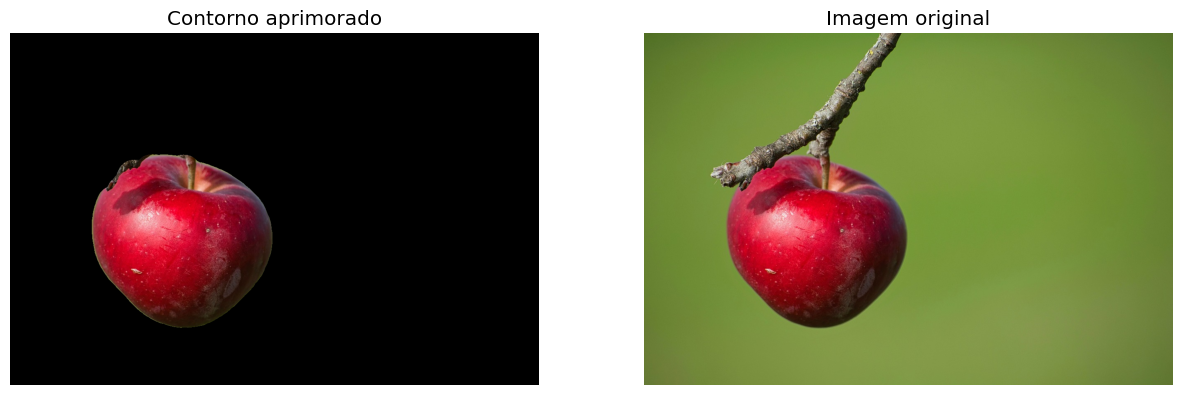

In [23]:
# Isola o fundo: qualquer pixel de matiz verde é considerado fundo
mask_fundo = cv2.inRange(hsv, (35, 30, 30), (85, 255, 255))
mask_objeto = cv2.bitwise_not(mask_fundo)  # tudo que não é fundo (maçã + galho + ruído)

# Erode com um kernel maior para afinar e desconectar o cabinho/galho da massa da maçã
kernel_abertura = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (85, 85))
mask_erodida = cv2.erode(mask_objeto, kernel_abertura)

# Mantém apenas o maior componente conectado da máscara erodida, descartando
# qualquer fragmento do galho/cabinho que ainda tenha sobrevivido à erosão
n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_erodida, connectivity=8)
maior_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])  # ignora o fundo (label 0)
mask_semente = np.uint8(labels == maior_label) * 255

# Dilata de volta apenas a semente da maçã, restaurando sua forma original
# sem trazer o galho de volta, já que ele foi descartado antes da dilatação
mask_sem_galho = cv2.dilate(mask_semente, kernel_abertura)

# Seleciona apenas o maior componente conectado (a maçã)
contornos, _ = cv2.findContours(mask_sem_galho, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
maior_contorno = max(contornos, key = cv2.contourArea)

# Preenche o contorno real preservando a forma orgânica.
# Preencher o contorno externo já fecha buracos internos (reflexos/sombras),
# sem precisar "esticar" retas que apagam as concavidades verdadeiras
mask_final = np.zeros_like(mask)
cv2.drawContours(mask_final, [maior_contorno], -1, 255, thickness = cv2.FILLED)

# Aplica a máscara final na imagem original
resultado_final = cv2.bitwise_and(img, img, mask = mask_final)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(resultado_final[:, :, ::-1])
ax[0].set_title('Contorno aprimorado')
ax[0].axis('off')
ax[1].imshow(img[:, :, ::-1])
ax[1].set_title('Imagem original')
ax[1].axis('off')
plt.show()

## Validando o resultado com defeitos de convexidade

Antes de aceitar o resultado morfológico como definitivo, vale checar se ainda sobrou algo capaz de ser melhorado no contorno. Para isso, usamos os **defeitos de convexidade** (`cv2.convexityDefects`): a diferença entre o contorno real da maçã e seu Convex Hull, medida em cada reentrância. Defeitos rasos e localizados seriam candidatos a resíduos indesejados (como um resto de galho); defeitos mais largos ou mais profundos tendem a ser concavidades naturais da fruta.

Como o contorno bruto segue cada pixel da borda, ele gera dezenas de "micro defeitos" irrelevantes (a serrilha natural da máscara). Por isso, simplificamos o contorno com `cv2.approxPolyDP` antes de calcular os defeitos, e exibimos apenas os 10 mais profundos.

O resultado mostra que os defeitos remanescentes correspondem apenas à covinha natural onde o cabo se encaixa na maçã — uma característica legítima da fruta, não um erro de segmentação. Isso confirma que a máscara obtida com o kernel de erosão (85x85) já está adequada, sem a necessidade de um corte adicional no contorno.

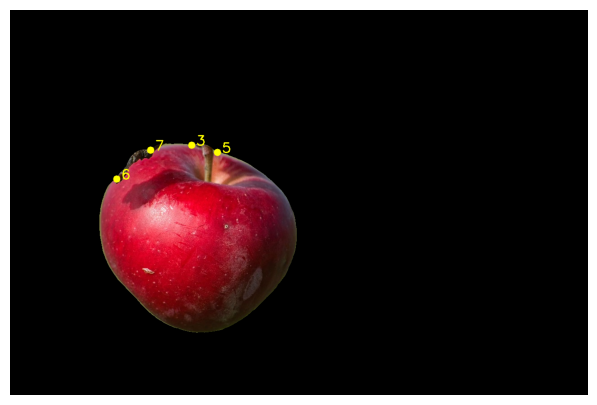

In [24]:
# Simplifica o contorno antes de calcular os defeitos: reduz o número de pontos,
# eliminando a serrilha de pixel a pixel que gera "micro defeitos" irrelevantes
perimetro = cv2.arcLength(maior_contorno, True)
contorno_simplificado = cv2.approxPolyDP(maior_contorno, 0.001 * perimetro, True)

# Recalcula o hull e os defeitos em cima do contorno simplificado
hull_indices = cv2.convexHull(contorno_simplificado, returnPoints=False)
defeitos = cv2.convexityDefects(contorno_simplificado, hull_indices)

# Desenha os defeitos mais relevantes (maior profundidade)
img_defeitos = resultado_final.copy()

# Ordena os defeitos da maior para a menor profundidade e pega apenas os 10 principais
defeitos_ordenados = sorted(defeitos, key=lambda d: d[0][3], reverse=True)[:10]

for defeito in defeitos_ordenados:
    inicio_idx, fim_idx, ponto_fundo_idx, profundidade = defeito[0]
    ponto_fundo = tuple(contorno_simplificado[ponto_fundo_idx][0])
    profundidade_px = profundidade / 256.0

    cv2.circle(img_defeitos, ponto_fundo, 8, (0, 255, 255), -1)
    cv2.putText(img_defeitos, f'{profundidade_px:.0f}',
                (ponto_fundo[0] + 10, ponto_fundo[1]),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)

plt.figure(figsize=(15, 5))
plt.imshow(img_defeitos[:, :, ::-1])
plt.axis('off')
plt.show()

**Conclusão**

Os defeitos remanescentes nos pontos 3 e 5 correspondem à covinha natural onde o cabo se encaixa na maçã. Já os pontos 6 e 7 marcam uma região de **oclusão**: nesse trecho, o galho passa na frente da maçã na imagem original, cobrindo uma pequena parte real da sua superfície. Diferente dos problemas de segmentação tratados até aqui (fundo verde, sombras, reflexos), esse é um limite de informação — os pixels da maçã ali escondida não existem na foto, então nenhuma operação morfológica ou de contorno pode reconstruí-los. O contorno reentrando levemente nesse ponto reflete corretamente essa oclusão, e não um erro a ser corrigido.